In [52]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()

twopi = 2.*np.pi
L = twopi
N = 512
D = 2
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]
dx = L/N
dk = twopi/L


In [53]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def imshow_cbar(ar, fig, ax, ax_kwargs={}, cbar_kwargs={}, noticks=True, cbar=True):
    im = ax.imshow(ar, **ax_kwargs)
    if cbar:
        divider = make_axes_locatable(ax)
        # size='5%', pad=0.05
        if len(cbar_kwargs) == 0:
            cbar_kwargs = {'size': '5%', 'pad': 0.05}
        cax = divider.append_axes('right', **cbar_kwargs)
        fig.colorbar(im, cax=cax, orientation='vertical')
    if noticks:
        ax.set_xticks([])
        ax.set_yticks([])
    return im

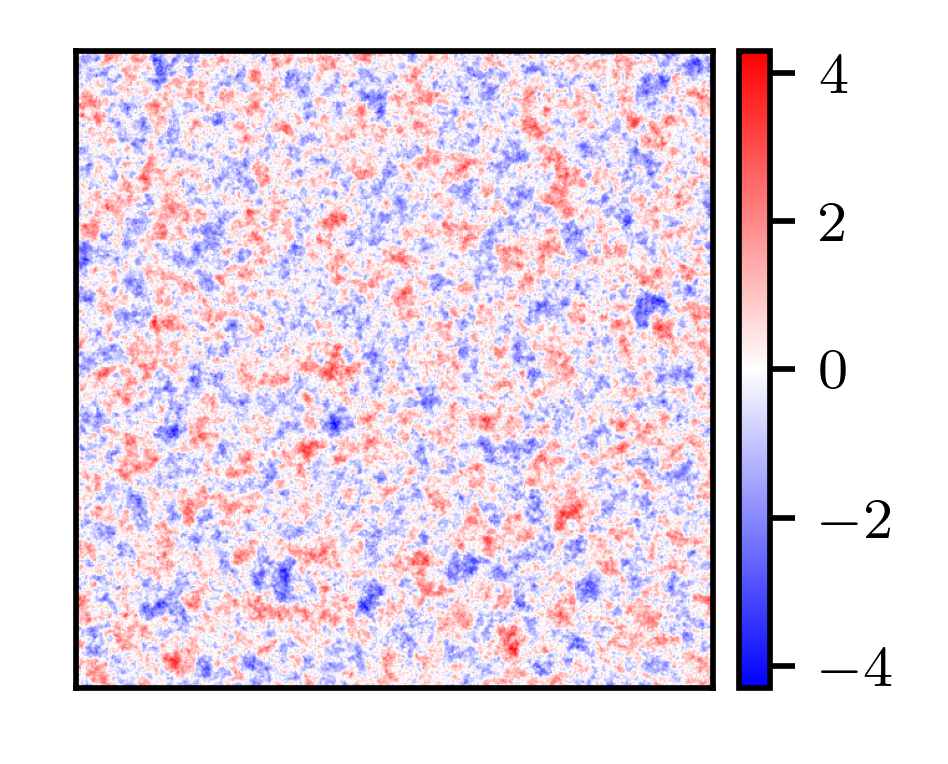

In [54]:

file0 = h5.File('SF_TEST/2_512/in/T.Fr.h5', 'r')
field0 = np.array(file0['T.Fr'])

file = h5.File('SF_TEST/2_512/out/SF_Grid_scalar_mine.h5', 'r')
sf_f = np.array(file['SF_Grid_scalar2'])

file2 = h5.File('SF_TEST/2_512/out/SF_Grid_scalar.h5', 'r')
sf_f2 = np.array(file2['SF_Grid_scalar2'])

file3 = h5.File('SF_TEST/2_512/out/SF_Grid_scalar_mine_periodic.h5', 'r')
sf_f3 = np.array(file3['SF_Grid_scalar2'])

fig, ax = plt.subplots(1, 1, figsize=(1.75, 1.75), dpi=512)
cmin, cmax = plotting.get_minmax(field0)
imshow_cbar(field0, fig, ax, ax_kwargs={'origin': 'lower', 'cmap': 'bwr', 'vmin': cmin, 'vmax': cmax})


/tmp/ipykernel_71954/1104021265.py:14: UserWarning: The following kwargs were not used by contour: 'linestyle'
  im2 = ax[0].contour(X, Y, sf_f[256:,256:].transpose(), contours, linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
/tmp/ipykernel_71954/1104021265.py:18: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[1].contour(X, Y, sf_f2, contours, linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
/tmp/ipykernel_71954/1104021265.py:22: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[2].contour(X, Y, sf_f3[256:,256:], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)


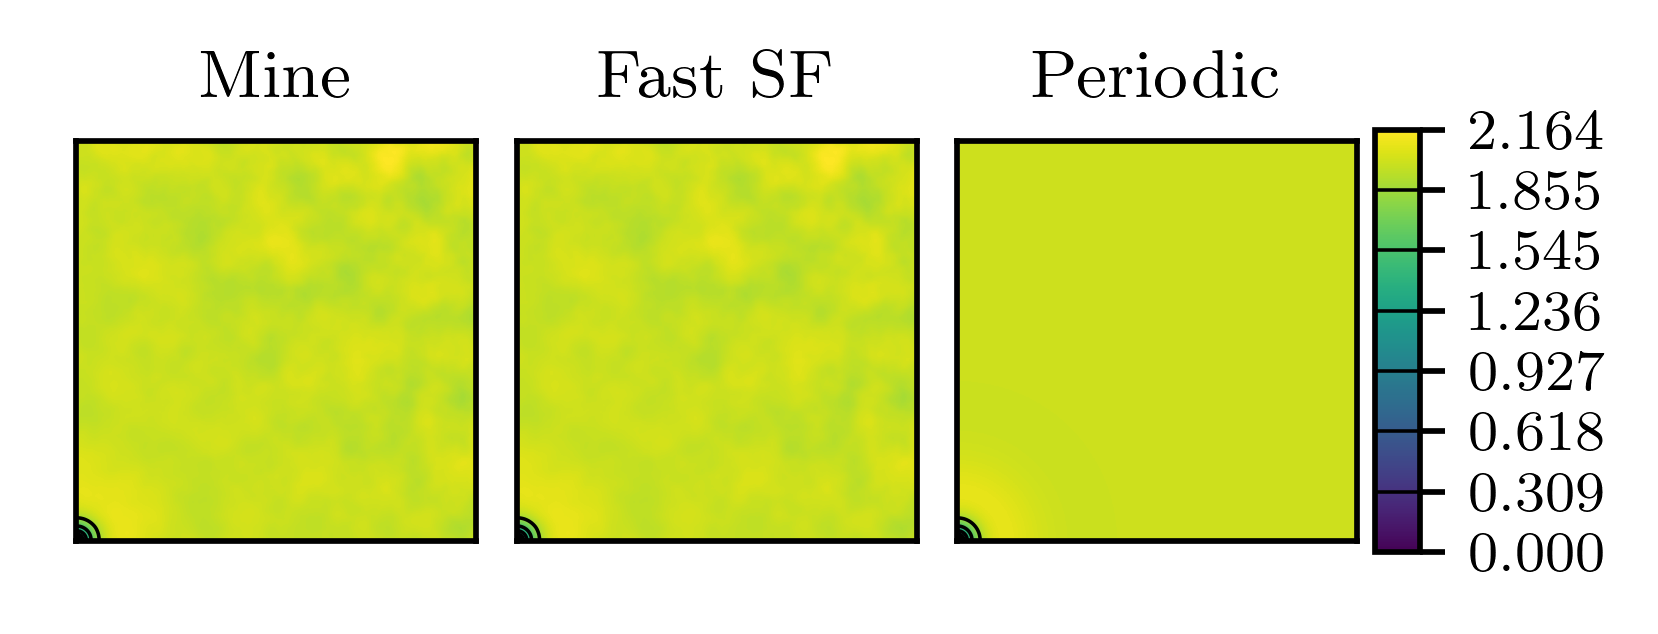

In [55]:

X, Y = np.meshgrid(np.arange(0, 256, 1), np.arange(0, 256, 1))

fig, ax = plt.subplots(1, 3, figsize=(3.5, 8.25), dpi=512)

#sf_f3 = np.zeros_like(sf_f)

cmin = np.nanmin([np.nanmin(sf_f[256:,256:].transpose()), np.nanmin(sf_f2), np.nanmin(sf_f3)])
#cmin = np.nanmin([np.nanmin(sf_f[256:,256:].transpose()[sf_f[256:,256:]>0.]), np.nanmin(sf_f2[sf_f2>0.]), np.nanmin(sf_f3[sf_f3>0.])])
cmax = np.nanmax([np.nanmax(sf_f[256:,256:].transpose()), np.nanmax(sf_f2), np.nanmax(sf_f3)])

contours = np.linspace(cmin, cmax, 8)

im = imshow_cbar(sf_f[256:,256:].transpose(), fig, ax[0], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
im2 = ax[0].contour(X, Y, sf_f[256:,256:].transpose(), contours, linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[0].set_title('Mine')

imshow_cbar(sf_f2, fig, ax[1], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
ax[1].contour(X, Y, sf_f2, contours, linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[1].set_title('Fast SF')

imshow_cbar(sf_f3[256:,256:], fig, ax[2], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
ax[2].contour(X, Y, sf_f3[256:,256:], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[2].set_title('Periodic')


fig.subplots_adjust(right=0.84)
cbar_ax = fig.add_axes([0.85, 0.4525, 0.025, 0.1])
cax = fig.colorbar(im, cax=cbar_ax)
fig.colorbar(im2, cax=cbar_ax)

fig.subplots_adjust(hspace=0., wspace=0.1)

fig.savefig('SF_TEST/2_512/out/SF_2d_plot.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()


In [56]:

print(np.where(sf_f == np.min(sf_f)))

sf_f2_full = np.zeros_like(sf_f)
sf_f2_full[256:,256:] = sf_f2
sf_f2_full[:256,256:] = sf_f2[::-1]
sf_f2_full[256:,:256] = sf_f2[:,::-1]
sf_f2_full[:256,:256] = sf_f2[::-1,::-1]

print(np.where(sf_f2_full == np.min(sf_f2_full)))


(array([256]), array([256]))
(array([255, 255, 256, 256]), array([255, 256, 255, 256]))


/tmp/ipykernel_71954/1443373826.py:13: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(X, Y, sf_f[256-n:256+n,256-n:256+n].transpose(), np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
/tmp/ipykernel_71954/1443373826.py:17: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[1].contour(X, Y, sf_f2_full[256-n:256+n,256-n:256+n], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
/tmp/ipykernel_71954/1443373826.py:21: UserWarning: The following kwargs were not used by contour: 'linestyle'
  im2 = ax[2].contour(X, Y, sf_f3[256-n:256+n,256-n:256+n], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)


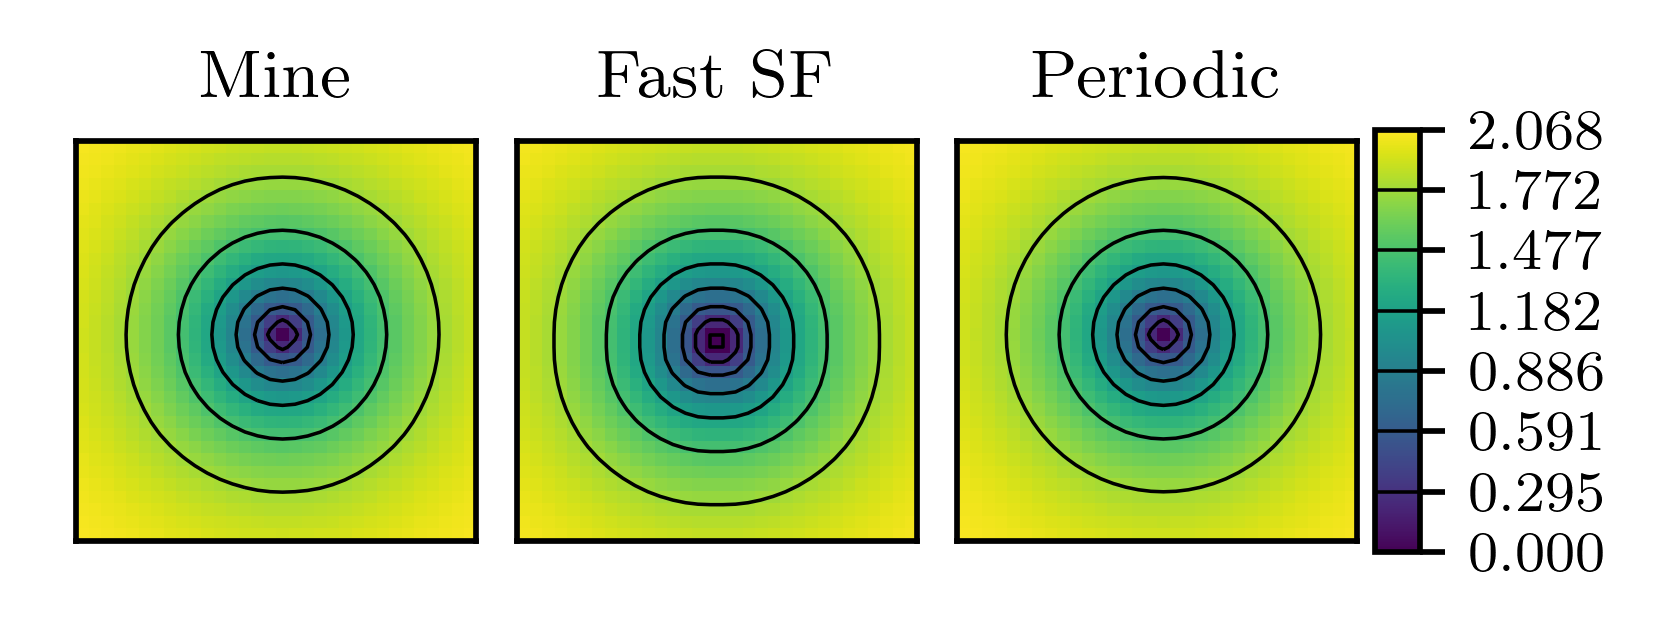

In [104]:
n = 16

X, Y = np.meshgrid(np.arange(0, 2*n, 1), np.arange(0, 2*n, 1))

#, 'norm': LogNorm()

fig, ax = plt.subplots(1, 3, figsize=(3.5, 8.25), dpi=512)

cmin = np.nanmin([np.nanmin(sf_f[256-n:256+n,256-n:256+n].transpose()), np.nanmin(sf_f2[256-n:256+n,256-n:256+n]), np.nanmin(sf_f3[256-n:256+n,256-n:256+n])])
cmax = np.nanmax([np.nanmax(sf_f[256-n:256+n,256-n:256+n].transpose()), np.nanmax(sf_f2[256-n:256+n,256-n:256+n]), np.nanmax(sf_f3[256-n:256+n,256-n:256+n])])

imshow_cbar(sf_f[256-n:256+n,256-n:256+n].transpose(), fig, ax[0], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
ax[0].contour(X, Y, sf_f[256-n:256+n,256-n:256+n].transpose(), np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[0].set_title('Mine')

imshow_cbar(sf_f2_full[256-n:256+n,256-n:256+n], fig, ax[1], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
ax[1].contour(X, Y, sf_f2_full[256-n:256+n,256-n:256+n], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[1].set_title('Fast SF')

im = imshow_cbar(sf_f3[256-n:256+n,256-n:256+n], fig, ax[2], ax_kwargs={'origin': 'lower', 'cmap': 'viridis', 'vmin': cmin, 'vmax': cmax}, cbar=False)
im2 = ax[2].contour(X, Y, sf_f3[256-n:256+n,256-n:256+n], np.linspace(cmin, cmax, 8), linewidths=0.5, linestyle=':', colors='black', vmin=cmin, vmax=cmax)
ax[2].set_title('Periodic')

fig.subplots_adjust(right=0.84)
cbar_ax = fig.add_axes([0.85, 0.4525, 0.025, 0.1])
cax = fig.colorbar(im, cax=cbar_ax)
fig.colorbar(im2, cax=cbar_ax)

fig.subplots_adjust(hspace=0., wspace=0.1)

fig.savefig('SF_TEST/2_512/out/SF_2d_plot_full.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()


In [241]:

bloc = 'center'
dxb = dx-dx/10.
NB = 8

lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
l_f, sf2_f, w_f = statistics_base.bin_data(lvm_f, sf_f, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dxb, max_bin=L/2., num_bins=N//NB, bin_loc=bloc, log_space=True)
l_f = l_f[np.isfinite(sf2_f)]
sf2_f = sf2_f[np.isfinite(sf2_f)]

lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
lvm_f = lvm_f[256:,256:]
l_f2, sf2_f2, w_f2 = statistics_base.bin_data(lvm_f, sf_f2, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dxb, max_bin=L/2., num_bins=N//NB, bin_loc=bloc, log_space=True)
l_f2 = l_f2[np.isfinite(sf2_f2)]
sf2_f2 = sf2_f2[np.isfinite(sf2_f2)]

lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
l_f2_full, sf2_f2_full, w_f2_full = statistics_base.bin_data(lvm_f, sf_f2_full, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dxb, max_bin=L/2., num_bins=N//NB, bin_loc=bloc, log_space=True)
l_f2_full = l_f2_full[np.isfinite(sf2_f2_full)]
sf2_f2_full = sf2_f2_full[np.isfinite(sf2_f2_full)]

lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx
l_f3, sf2_f3, w_f3 = statistics_base.bin_data(lvm_f, sf_f3, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dxb, max_bin=L/2., num_bins=N//NB, bin_loc=bloc, log_space=True)
print(1./np.min(lvm_f[lvm_f != 0.]), 1./np.nanmin(l_f3), 1./dx)
# plt.scatter(np.arange(0, len(sf2_f3)), sf2_f3)
# plt.xlim((0., 25))
# plt.ylim((-0.1, 10))
# plt.axvline(dx)
l_f3 = l_f3[np.isfinite(sf2_f3)]
print(1./np.min(lvm_f[lvm_f != 0.]), 1./np.nanmin(l_f3), 1./dx)
sf2_f3 = sf2_f3[np.isfinite(sf2_f3)]


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


81.48733086305042 86.54713497609892 81.48733086305042
81.48733086305042 79.23352655749342 81.48733086305042


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


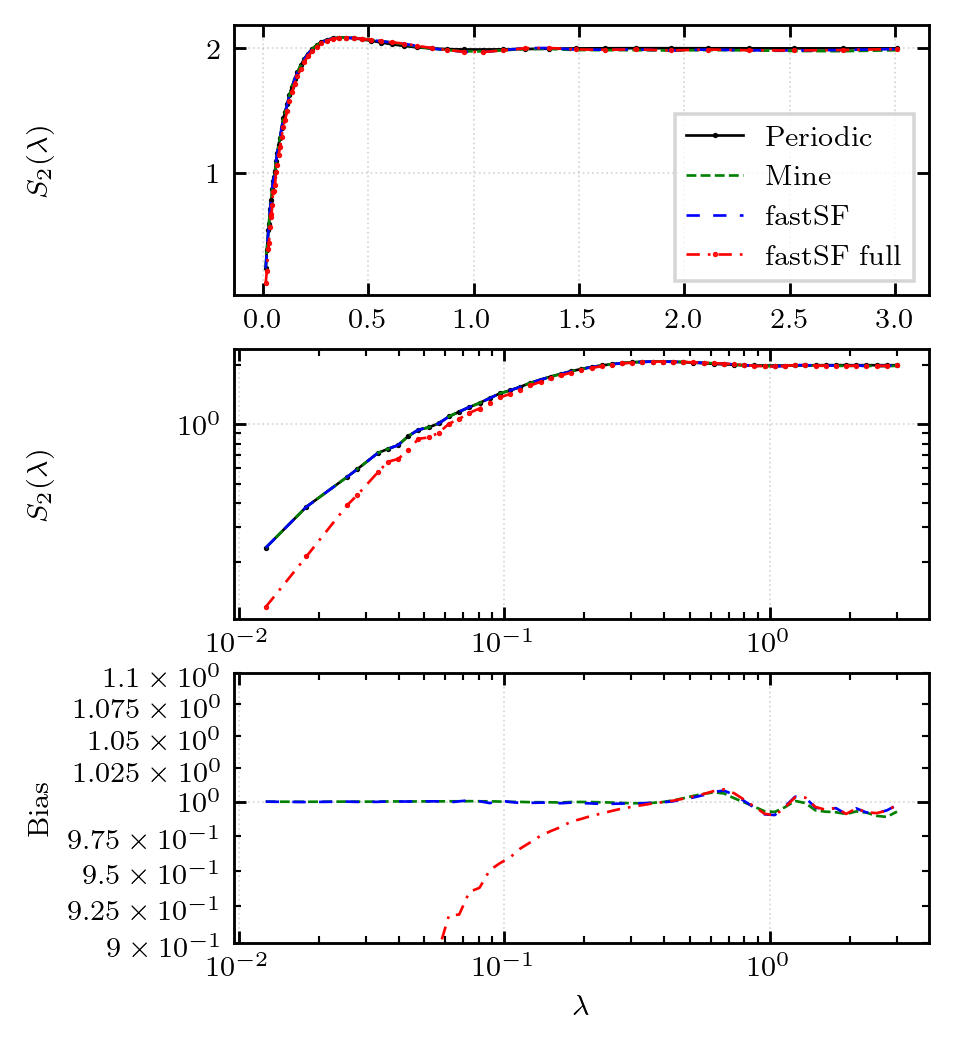

In [242]:

fig, ax = plt.subplots(3, 1, dpi=256, figsize=(3.5, 4.75))

for axx in [ax[0], ax[1]]:
    axx.plot(l_f3, sf2_f3, linestyle='-', marker='.', markersize=1., linewidth=0.75, color='black', label='Periodic')
    axx.plot(l_f, sf2_f, linestyle='--', linewidth=0.75, color='green', label='Mine')
    axx.plot(l_f2, sf2_f2, linestyle=(0,(5,5)), linewidth=0.75, color='blue', label='fastSF')
    axx.plot(l_f2_full, sf2_f2_full, marker='.', markersize=1., linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='fastSF full')

ax[2].plot(l_f, sf2_f/sf2_f3, linestyle='--', linewidth=0.75, color='green', label='Mine')
ax[2].plot(l_f2, sf2_f2/sf2_f3, linestyle=(0,(5,5)), linewidth=0.75, color='blue', label='fastSF')
ax[2].plot(l_f2_full, sf2_f2_full/sf2_f3,linestyle=(0,(5,3,1,3)), linewidth=0.75, color='red', label='fastSF full')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_ylabel(r'$S_2(\lambda)$')
ax[1].set_ylabel(r'$S_2(\lambda)$')
ax[2].set_ylabel(r'Bias')

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[2].set_ylim((9e-1, 1.1e0))

ax[2].set_xlabel(r'$\lambda$')

ax[0].legend(fancybox=False)

fig.align_ylabels()


Text(0, 0.5, 'PSD, $\\mathcal{E}(k)$ [arb. units]')

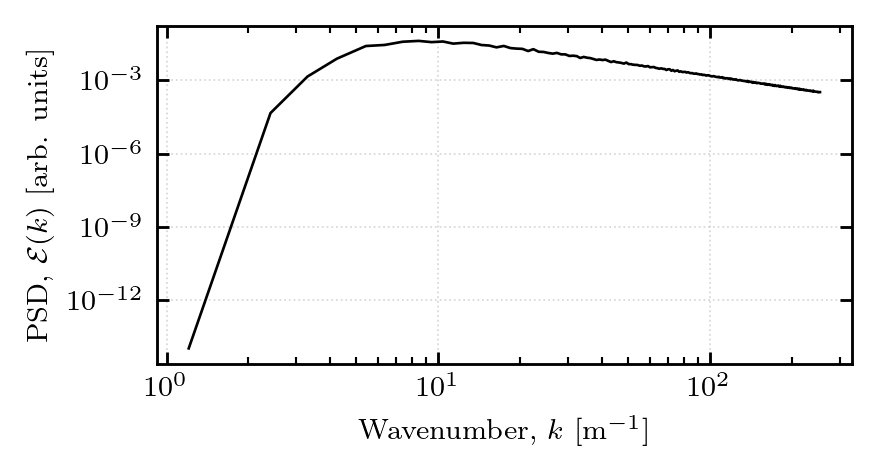

In [243]:
kD, fekD = per_spectra.modal_spectrum(field0, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)

fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
ax.plot(ko, feko, linestyle='-', color='black', linewidth=0.75)
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Wavenumber, $k$ [m$^{-1}$]')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$ [arb. units]')

In [244]:
from Kea.statistics.spectra import strfn_spectra

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=1., b=1.):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    kmin = np.nanmin(ko)
    kmax = np.nanmax(kk)
    ki = ko[ko <= kmax]

    fek = strfn_spectra.interpolate(kk, fek, ki)

    fek = fek[ki >= kmin]
    return ki, fek

k_f3, fek_f3 = omni_spectrum(l_f3, sf2_f3, phys_dims, grid_dims)
k_f, fek_f = omni_spectrum(l_f, sf2_f, phys_dims, grid_dims)
k_f2, fek_f2 = omni_spectrum(l_f2, sf2_f2, phys_dims, grid_dims)
k_f2_full, fek_f2_full = omni_spectrum(l_f2_full, sf2_f2_full, phys_dims, grid_dims)


/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


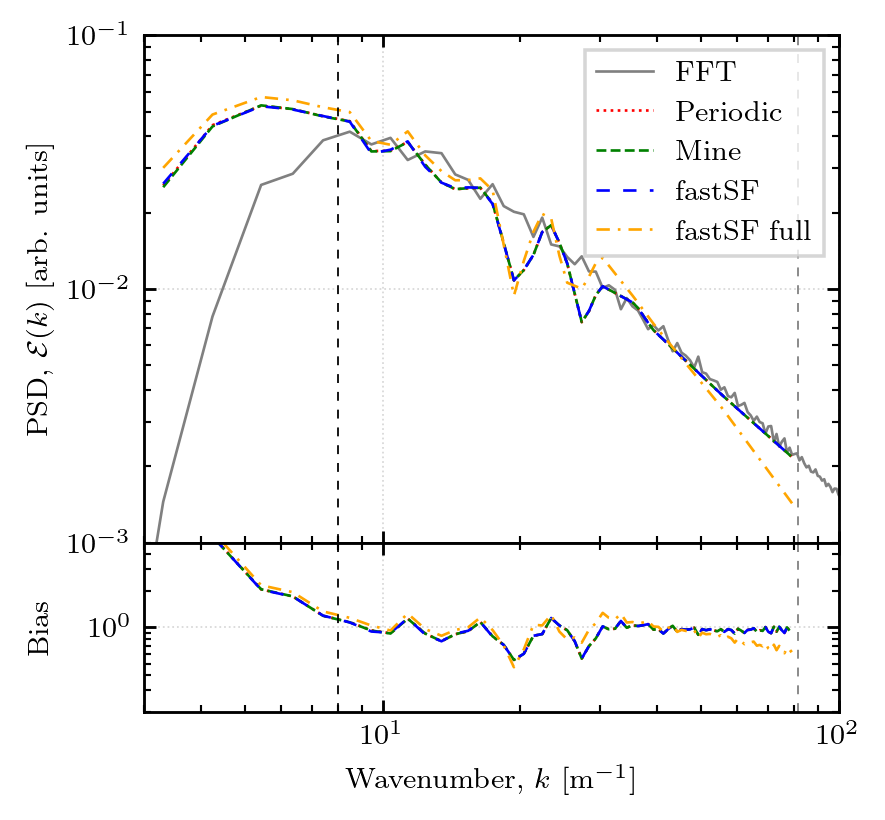

In [248]:

fig = plt.figure(1, dpi=256, figsize=(3.5, 3.5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.05)

ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

ax[0].plot(ko, feko, linestyle='-', linewidth=0.75, color='gray', label='FFT')

ax[0].plot(k_f3, fek_f3, linestyle=':', linewidth=0.75, color='red', label='Periodic')
ax[0].plot(k_f, fek_f, linestyle='--', linewidth=0.75, color='green', label='Mine')
ax[0].plot(k_f2, fek_f2, linestyle=(0,(5,5)), linewidth=0.75, color='blue', label='fastSF')
ax[0].plot(k_f2_full, fek_f2_full, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='orange', label='fastSF full')

kmax = np.max(k_f)
k_same = ko[ko <= kmax]
fek_same = feko[ko <= kmax]

ax[1].plot(k_f3, fek_f3/fek_same, linestyle=':', linewidth=0.75, color='red', label='Periodic')
ax[1].plot(k_f, fek_f/fek_same, linestyle='--', linewidth=0.75, color='green', label='Mine')
ax[1].plot(k_f2, fek_f2/fek_same, linestyle=(0,(5,5)), linewidth=0.75, color='blue', label='fastSF')
ax[1].plot(k_f2_full, fek_f2_full/fek_same, linestyle=(0,(5,3,1,3)), linewidth=0.75, color='orange', label='fastSF full')

for axx in ax:
    axx.set_yscale('log')
    axx.set_xscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    axx.axvline(8.*dk, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    axx.axvline(1./dx, color='gray', linestyle=(0,(5,5)), linewidth=0.5)
    #axx.axvline(1./np.pi, color='gray', linestyle=(0,(5,5)), linewidth=0.5)

ax[0].set_xlim((3, 100))
ax[1].set_xlim(ax[0].get_xlim())

ax[0].set_xticklabels([])

ax[0].legend(frameon=True, fancybox=False)

ax[0].set_ylim((1e-3, 1e-1))
ax[1].set_ylim((2e-1, 5e0))

ax[0].set_ylabel(r'PSD, $\mathcal{E}(k)$ [arb. units]')
ax[1].set_xlabel(r'Wavenumber, $k$ [m$^{-1}$]')
ax[1].set_ylabel(r'Bias')

fig.align_ylabels()
